In [1]:
import matplotlib.pyplot as plt
import numpy as np
import random

# Mock config loader
CONFIG = {
    "SPEED_PROFILES": {
        "test_speed": {
            "max_linear_speed": 50.0,  # Max 10.0 cm/s
            "max_angular_speed": 3.0,  # Max 6.0 rad/s
            "max_linear_acceleration": 50.0,  # Max 0.5 cm/s^2
            "max_angular_acceleration": 0.1, # Max 1.0 rad/s^2
            "max_linear_deceleration": 50.0,  # Max 0.5 cm/s^2
            "max_angular_deceleration": 0.1  # Max 1.0 rad/s^2
        }
    }
}

import sys

sys.path.append(
    r"C:\Users\floot\Florian's Laptop\ESILV\CDR\CoupeDeRobotique\common"
)


from travel_supervisor import TravelSupervisor

from geometry import OrientedPoint
import time
# Import MovementSupervisor et Curve ici

# Générer une trajectoire simple (par exemple, un arc de cercle)
def generate_test_trajectory():
    trajectory = []
    
    num_points = 100
    for x in np.linspace(0, 50, num_points):
        trajectory.append(OrientedPoint(x, 0, 0)) 
    
    return trajectory

# Initialiser MovementSupervisor
trajectory = generate_test_trajectory()
trajectory

[POINT (0 0), theta: 0,
 POINT (0.5050505050505051 0), theta: 0,
 POINT (1.0101010101010102 0), theta: 0,
 POINT (1.5151515151515151 0), theta: 0,
 POINT (2.0202020202020203 0), theta: 0,
 POINT (2.5252525252525255 0), theta: 0,
 POINT (3.0303030303030303 0), theta: 0,
 POINT (3.5353535353535355 0), theta: 0,
 POINT (4.040404040404041 0), theta: 0,
 POINT (4.545454545454546 0), theta: 0,
 POINT (5.050505050505051 0), theta: 0,
 POINT (5.555555555555556 0), theta: 0,
 POINT (6.0606060606060606 0), theta: 0,
 POINT (6.565656565656566 0), theta: 0,
 POINT (7.070707070707071 0), theta: 0,
 POINT (7.575757575757576 0), theta: 0,
 POINT (8.080808080808081 0), theta: 0,
 POINT (8.585858585858587 0), theta: 0,
 POINT (9.090909090909092 0), theta: 0,
 POINT (9.595959595959597 0), theta: 0,
 POINT (10.101010101010102 0), theta: 0,
 POINT (10.606060606060607 0), theta: 0,
 POINT (11.111111111111112 0), theta: 0,
 POINT (11.616161616161618 0), theta: 0,
 POINT (12.121212121212121 0), theta: 0,
 PO

In [2]:

supervisor = TravelSupervisor(profile=CONFIG["SPEED_PROFILES"]["test_speed"], linear_speed=0.0, angular_speed=0.0)
supervisor.set_trajectory(trajectory)
startime = supervisor.start_time

# Simulation des états futurs
time_step = 0.1
total_time = supervisor.total_duration
timestamps = np.arange(0, total_time, time_step)
print(total_time)

2.0


In [3]:
# Stocker les données pour visualisation
positions = []
linear_speeds = []
angular_speeds = []

for t in timestamps:
    state = supervisor.compute_future_state(time.time())
    positions.append([state[0].x, state[0].y])  # (x, y, theta)
    linear_speeds.append(state[1])  # Linear speed
    angular_speeds.append(state[2])  # Angular speed
    time.sleep(time_step)

In [4]:
positions

[[18.54278821555406, 0.0],
 [23.032511625568596, 0.0],
 [28.221384357966713, 0.0],
 [31.82906726396584, 0.0],
 [35.93272255928292, 0.0],
 [39.52984297766508, 0.0],
 [42.61676689244112, 0.0],
 [45.20033802436984, 0.0],
 [47.29040471805649, 0.0],
 [48.8731357788496, 0.0],
 [49.95708795357389, 0.0],
 [49.52544543932335, 0.0],
 [49.494949494949495, 0.0],
 [49.494949494949495, 0.0],
 [49.494949494949495, 0.0],
 [49.494949494949495, 0.0],
 [49.494949494949495, 0.0],
 [49.494949494949495, 0.0],
 [49.494949494949495, 0.0],
 [49.494949494949495, 0.0]]

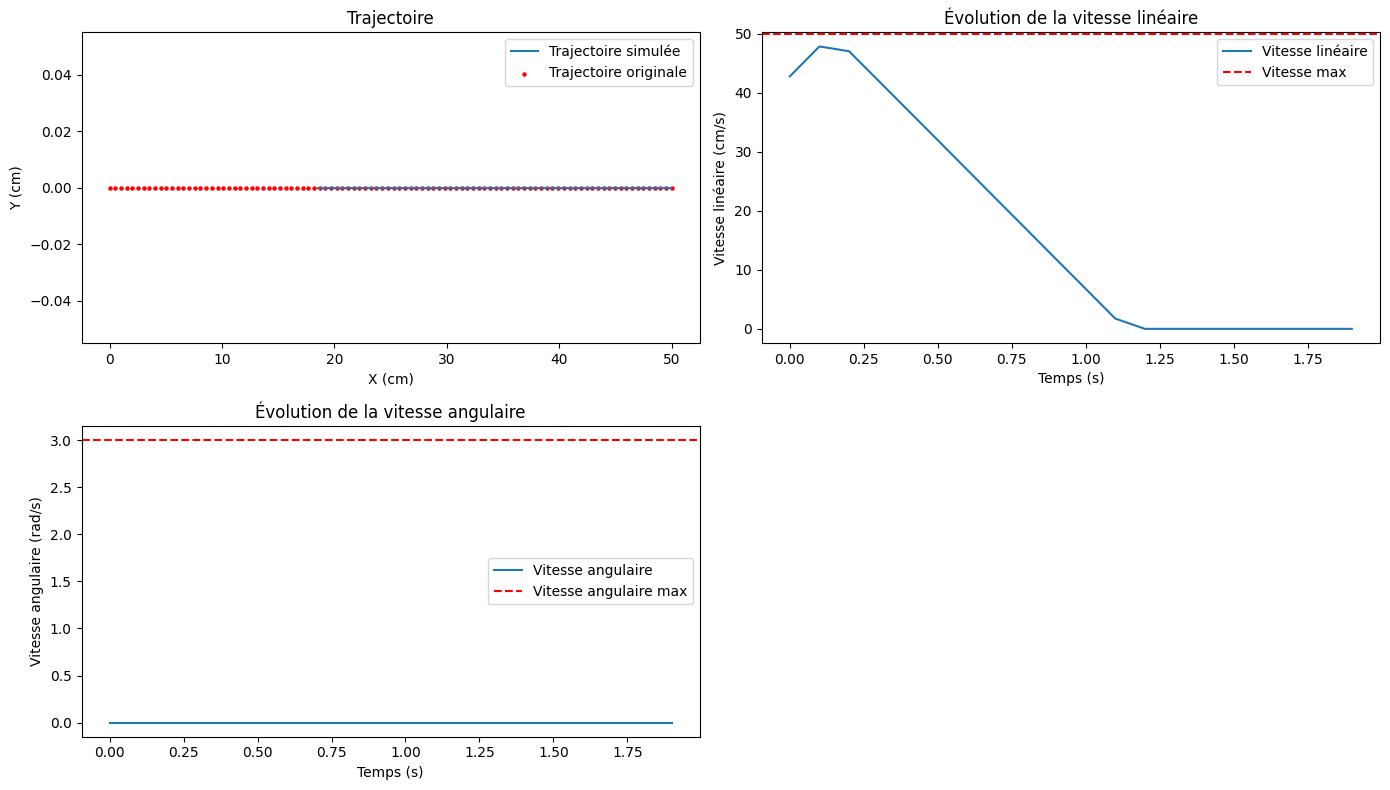

In [5]:
# Convertir en numpy pour les graphiques
linear_speeds = np.array(linear_speeds)
angular_speeds = np.array(angular_speeds)

# Visualisation
plt.figure(figsize=(14, 8))

# Trajectoire
plt.subplot(2, 2, 1)
plt.plot([pos[0] for pos in positions], [pos[1] for pos in positions], label="Trajectoire simulée")
plt.scatter([p.x for p in trajectory], [p.y for p in trajectory], s=5, label="Trajectoire originale", color="red")
plt.xlabel("X (cm)")
plt.ylabel("Y (cm)")
plt.title("Trajectoire")
plt.legend()

# Vitesse linéaire
plt.subplot(2, 2, 2)
plt.plot(timestamps, linear_speeds, label="Vitesse linéaire")
plt.axhline(CONFIG["SPEED_PROFILES"]["test_speed"]["max_linear_speed"], color='red', linestyle='--', label="Vitesse max")
plt.xlabel("Temps (s)")
plt.ylabel("Vitesse linéaire (cm/s)")
plt.title("Évolution de la vitesse linéaire")
plt.legend()

# Vitesse angulaire
plt.subplot(2, 2, 3)
plt.plot(timestamps, angular_speeds, label="Vitesse angulaire")
plt.axhline(CONFIG["SPEED_PROFILES"]["test_speed"]["max_angular_speed"], color='red', linestyle='--', label="Vitesse angulaire max")
plt.xlabel("Temps (s)")
plt.ylabel("Vitesse angulaire (rad/s)")
plt.title("Évolution de la vitesse angulaire")
plt.legend()

plt.tight_layout()
plt.show()

In [6]:
import math

class ClothoidTrajectoryGenerator:
    def __init__(self, start_point, start_orientation, curvature_change, num_segments, segment_length):
        """
        Génère une trajectoire basée sur des clothoïdes.
        :param start_point: Tuple (x, y) point de départ.
        :param start_orientation: Angle initial en radians.
        :param curvature_change: Taux de changement de courbure (κ').
        :param num_segments: Nombre de segments de clothoïde.
        :param segment_length: Longueur de chaque segment.
        """
        self.start_point = start_point
        self.start_orientation = start_orientation
        self.curvature_change = curvature_change
        self.num_segments = num_segments
        self.segment_length = segment_length

    def generate_trajectory(self):
        """
        Génère une liste de points sous la forme [((x, y), θ), ...].
        """
        trajectory = []
        x, y = self.start_point
        theta = self.start_orientation
        curvature = 0  # Curvature starts at 0
        
        for _ in range(self.num_segments):
            # Position update using the arc length and orientation
            dx = self.segment_length * math.cos(theta)
            dy = self.segment_length * math.sin(theta)
            x += dx
            y += dy
            
            # Append the current position and orientation
            trajectory.append(((x, y), theta))
            
            # Update curvature and orientation
            curvature += self.curvature_change * self.segment_length
            theta += curvature * self.segment_length
        
        return trajectory


# Exemple d'utilisation
start_point = (0, 0)
start_orientation = 0  # Robot oriented along x-axis
curvature_change = 0.01  # Small curvature change per unit length
num_segments = 100  # Number of segments to generate
segment_length = 0.1  # Length of each segment in meters

generator = ClothoidTrajectoryGenerator(start_point, start_orientation, curvature_change, num_segments, segment_length)
trajectory = generator.generate_trajectory()

# Utilisation avec MovementSupervisor
supervisor = TravelSupervisor(profile_name="cruise_speed", linear_speed=0.5, angular_speed=0.1)
supervisor.set_trajectory(trajectory)
# Stocker les données pour visualisation
positions = []
linear_speeds = []
angular_speeds = []

for t in timestamps:
    state = supervisor.compute_future_state(t)
    positions.append(state[0][0])  # (x, y)
    linear_speeds.append(state[1])  # Linear speed
    angular_speeds.append(state[2])  # Angular speed

# Convertir en numpy pour les graphiques
positions = np.array(positions)
linear_speeds = np.array(linear_speeds)
angular_speeds = np.array(angular_speeds)

# Visualisation
plt.figure(figsize=(14, 8))

# Trajectoire
plt.subplot(2, 2, 1)
plt.plot(positions[:, 0], positions[:, 1], label="Trajectoire simulée")
plt.scatter(*zip(*[p[0] for p in trajectory]), s=5, label="Trajectoire originale", color="red")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.title("Trajectoire")
plt.legend()

# Vitesse linéaire
plt.subplot(2, 2, 2)
plt.plot(timestamps, linear_speeds, label="Vitesse linéaire")
plt.axhline(supervisor.linear_speed, color='red', linestyle='--', label="Vitesse max")
plt.xlabel("Temps (s)")
plt.ylabel("Vitesse linéaire (m/s)")
plt.title("Évolution de la vitesse linéaire")
plt.legend()

# Vitesse angulaire
plt.subplot(2, 2, 3)
plt.plot(timestamps, angular_speeds, label="Vitesse angulaire")
plt.axhline(supervisor.angular_speed, color='red', linestyle='--', label="Vitesse angulaire max")
plt.xlabel("Temps (s)")
plt.ylabel("Vitesse angulaire (rad/s)")
plt.title("Évolution de la vitesse angulaire")
plt.legend()

plt.tight_layout()
plt.show()


IndentationError: expected an indented block after function definition on line 44 (105318987.py, line 45)